# FIFA Case Study - EDA and Statistical Analysis
### Name: Pushpalatha
### Project: Statistical for Machine Learning

## Step 1: Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"E:\ml project\project 3 (2)\project 3\fifa.csv")
df.head()

,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,240331,P. Camará,21,https://cdn.sofifa.org/players/4/19/240331.png,Guinea Bissau,https://cdn.sofifa.org/flags/119.png,58,69,Crawley Town,https://cdn.sofifa.org/teams/2/light/110890.png,...,46.0,14.0,18.0,15.0,7.0,9.0,9.0,6.0,15.0,€429K
1,183465,J. Rodwell,27,https://cdn.sofifa.org/players/4/19/183465.png,England,https://cdn.sofifa.org/flags/14.png,68,68,Blackburn Rovers,https://cdn.sofifa.org/teams/2/light/3.png,...,69.0,66.0,69.0,64.0,9.0,10.0,15.0,11.0,12.0,€1.8M
2,205186,P. Gazzaniga,26,https://cdn.sofifa.org/players/4/19/205186.png,Argentina,https://cdn.sofifa.org/flags/52.png,74,78,Tottenham Hotspur,https://cdn.sofifa.org/teams/2/light/18.png,...,55.0,23.0,20.0,11.0,76.0,73.0,84.0,72.0,76.0,€9.6M
3,233531,Y. Soteldo,21,https://cdn.sofifa.org/players/4/19/233531.png,Venezuela,https://cdn.sofifa.org/flags/61.png,71,81,Universidad de Chile,https://cdn.sofifa.org/teams/2/light/15029.png,...,65.0,25.0,23.0,20.0,13.0,7.0,9.0,13.0,6.0,€6.1M
4,243718,R. Koot,18,https://cdn.sofifa.org/players/4/19/243718.png,Netherlands,https://cdn.sofifa.org/flags/34.png,56,68,Fortuna Sittard,https://cdn.sofifa.org/teams/2/light/634.png,...,39.0,11.0,14.0,12.0,59.0,55.0,59.0,55.0,56.0,€198K


In [3]:
df.shape

(25490, 60)

## Step 2: Understand the Dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25490 entries, 0 to 25489
Data columns (total 60 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        25490 non-null  int64  
 1   Name                      25490 non-null  object 
 2   Age                       25490 non-null  int64  
 3   Photo                     25490 non-null  object 
 4   Nationality               25490 non-null  object 
 5   Flag                      25490 non-null  object 
 6   Overall                   25490 non-null  int64  
 7   Potential                 25490 non-null  int64  
 8   Club                      25159 non-null  object 
 9   Club Logo                 25490 non-null  object 
 10  Value                     25490 non-null  object 
 11  Wage                      25490 non-null  object 
 12  Preferred Foot            25425 non-null  object 
 13  International Reputation  25425 non-null  float64
 14  Weak F

In [5]:
df.describe()

,ID,Age,Overall,Potential,International Reputation,Weak Foot,Skill Moves,Jersey Number,Crossing,Finishing,...,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes
count,25490.000000,25490.000000,25490.000000,25490.000000,25425.000000,25425.000000,25425.000000,25401.000000,25425.000000,25425.000000,...,25425.000000,25425.000000,25425.000000,25425.000000,25425.000000,25425.000000,25425.000000,25425.000000,25425.000000,25425.000000
mean,214357.925343,25.114162,66.261593,71.338486,1.109302,2.949656,2.368181,19.576788,49.881180,45.662694,...,48.663559,58.749853,47.438033,47.816087,45.730305,16.568220,16.349066,16.230718,16.342852,16.665998
std,29878.130401,4.649341,6.843978,6.112496,0.385040,0.661157,0.758538,15.988779,18.356056,19.447835,...,15.683216,11.387027,19.768914,21.578577,21.181263,17.655976,16.848998,16.516029,16.982910,17.940949
min,16.000000,16.000000,46.000000,48.000000,1.000000,1.000000,1.000000,1.000000,5.000000,2.000000,...,5.000000,3.000000,3.000000,2.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,200353.750000,21.000000,62.000000,67.000000,1.000000,3.000000,2.000000,9.000000,38.000000,30.000000,...,39.000000,51.000000,30.000000,27.000000,24.000000,8.000000,8.000000,8.000000,8.000000,8.000000
50%,221816.000000,25.000000,66.000000,71.000000,1.000000,3.000000,2.000000,17.000000,54.000000,49.000000,...,50.000000,60.000000,53.000000,55.000000,52.000000,11.000000,11.000000,11.000000,11.000000,11.000000
75%,236545.000000,28.000000,71.000000,75.000000,1.000000,3.000000,3.000000,26.000000,64.000000,62.000000,...,60.000000,67.000000,64.000000,66.000000,64.000000,14.000000,14.000000,14.000000,14.000000,14.000000
max,246620.000000,45.000000,94.000000,95.000000,5.000000,5.000000,5.000000,99.000000,93.000000,94.000000,...,90.000000,95.000000,94.000000,93.000000,91.000000,90.000000,92.000000,88.000000,90.000000,94.000000


### Understanding the Dataset (Statistical Summary)

The df.describe() function provides a statistical summary of numerical features in the dataset.

### Key Observations:
- The average age of players is around 25 years, indicating a relatively young player base.
- The average overall rating is around 66, showing moderate skill levels.
- The standard deviation indicates variation in player attributes.
- The minimum and maximum values help identify extreme cases.
- Quartiles (25%, 50%, 75%) will be used later for outlier detection using the IQR method.

## Step 3: Data Cleaning

### 3.1: Checking for duplicates

In [6]:
df.duplicated().sum()

np.int64(11833)

In [7]:
df[df.duplicated()].head(10)

,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
152,211732,T. Thiele,26,https://cdn.sofifa.org/players/4/19/211732.png,Germany,https://cdn.sofifa.org/flags/21.png,67,68,1. FC Kaiserslautern,https://cdn.sofifa.org/teams/2/light/29.png,...,68.0,18.0,16.0,17.0,15.0,8.0,15.0,13.0,11.0,€1.4M
290,227708,Lucas Tagliapietra,27,https://cdn.sofifa.org/players/4/19/227708.png,Brazil,https://cdn.sofifa.org/flags/54.png,69,71,Al Batin,https://cdn.sofifa.org/teams/2/light/112990.png,...,65.0,58.0,71.0,66.0,10.0,11.0,9.0,12.0,6.0,€1.8M
321,240584,B. Verbong,18,https://cdn.sofifa.org/players/4/19/240584.png,Netherlands,https://cdn.sofifa.org/flags/34.png,58,70,VVV-Venlo,https://cdn.sofifa.org/teams/2/light/100651.png,...,42.0,13.0,14.0,12.0,61.0,59.0,60.0,52.0,58.0,€264K
373,231823,J. Hoogma,20,https://cdn.sofifa.org/players/4/19/231823.png,Netherlands,https://cdn.sofifa.org/flags/34.png,69,80,TSG 1899 Hoffenheim,https://cdn.sofifa.org/teams/2/light/10029.png,...,63.0,67.0,72.0,69.0,11.0,13.0,14.0,7.0,9.0,€3M
378,238160,M. Demiral,20,https://cdn.sofifa.org/players/4/19/238160.png,Turkey,https://cdn.sofifa.org/flags/48.png,73,83,Alanyaspor,https://cdn.sofifa.org/teams/2/light/113142.png,...,61.0,74.0,77.0,73.0,15.0,7.0,13.0,6.0,11.0,NaN
444,220030,G. Paquiez,24,https://cdn.sofifa.org/players/4/19/220030.png,France,https://cdn.sofifa.org/flags/18.png,65,68,Nîmes Olympique,https://cdn.sofifa.org/teams/2/light/224.png,...,58.0,62.0,60.0,65.0,15.0,12.0,7.0,8.0,16.0,€1.2M
460,205186,P. Gazzaniga,26,https://cdn.sofifa.org/players/4/19/205186.png,Argentina,https://cdn.sofifa.org/flags/52.png,74,78,Tottenham Hotspur,https://cdn.sofifa.org/teams/2/light/18.png,...,55.0,23.0,20.0,11.0,76.0,73.0,84.0,72.0,76.0,€9.6M
469,216744,C. Burgess,22,https://cdn.sofifa.org/players/4/19/216744.png,Australia,https://cdn.sofifa.org/flags/195.png,63,72,Scunthorpe United,https://cdn.sofifa.org/teams/2/light/1949.png,...,60.0,62.0,65.0,65.0,9.0,13.0,14.0,15.0,7.0,€975K
471,242458,A. Dovbyk,21,https://cdn.sofifa.org/players/4/19/242458.png,Ukraine,https://cdn.sofifa.org/flags/49.png,63,73,FC Midtjylland,https://cdn.sofifa.org/teams/2/light/1516.png,...,46.0,32.0,19.0,13.0,13.0,13.0,5.0,12.0,10.0,€900K
548,226697,M. Laínez,22,https://cdn.sofifa.org/players/4/19/226697.png,Mexico,https://cdn.sofifa.org/flags/83.png,66,72,Lobos BUAP,https://cdn.sofifa.org/teams/2/light/111035.png,...,60.0,56.0,59.0,56.0,6.0,8.0,14.0,7.0,10.0,€1.6M


In [8]:
df.duplicated(subset='ID').sum()

np.int64(11833)

In [9]:
df = df.drop_duplicates(subset='ID')

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.shape

(13657, 60)

### Checking for Duplicates

Duplicate records were identified in the dataset. 
Since the 'ID' column should uniquely identify each player, duplicate IDs indicate repeated entries.

After verification, duplicate rows were removed by keeping the first occurrence of each unique ID. 
Post-cleaning, no duplicate records remain in the dataset.

## 3.2: Missing Values

In [12]:
df.isnull().sum().sort_values(ascending=False)

Loaned From                 12714
Release Clause               1171
Joined                       1164
Contract Valid Until          221
Club                          185
Position                       47
Jersey Number                  47
Skill Moves                    36
International Reputation       36
Weak Foot                      36
Body Type                      36
Preferred Foot                 36
Weight                         36
Crossing                       36
Finishing                      36
Height                         36
HeadingAccuracy                36
Reactions                      36
Agility                        36
SprintSpeed                    36
Curve                          36
BallControl                    36
LongPassing                    36
FKAccuracy                     36
Volleys                        36
Dribbling                      36
ShortPassing                   36
Work Rate                      36
Strength                       36
LongShots     

In [13]:
df['Loaned From'] = df['Loaned From'].fillna('Not Loaned')

In [14]:
df['Club'] = df['Club'].fillna('Unknown')

In [15]:
df.dropna(subset=[
    'Skill Moves','International Reputation','Weak Foot','Body Type',
    'Preferred Foot','Weight','Crossing','Finishing','HeadingAccuracy',
    'Reactions','Agility','SprintSpeed','Curve','BallControl',
    'LongPassing','FKAccuracy','Volleys'
], inplace=True)

In [16]:
df.isnull().sum().sort_values(ascending=False)

Release Clause              1135
Joined                      1128
Contract Valid Until         185
Jersey Number                 11
Position                      11
Nationality                    0
Overall                        0
Flag                           0
ID                             0
Name                           0
Age                            0
Potential                      0
Wage                           0
Value                          0
Club Logo                      0
Club                           0
Skill Moves                    0
Weak Foot                      0
Preferred Foot                 0
International Reputation       0
Work Rate                      0
Body Type                      0
Loaned From                    0
Height                         0
Weight                         0
Crossing                       0
Finishing                      0
Photo                          0
HeadingAccuracy                0
ShortPassing                   0
Dribbling 

In [17]:
df['Position'] = df['Position'].fillna(df['Position'].mode()[0])

In [18]:
df.drop('Jersey Number', axis=1, inplace=True)

In [19]:
df.shape

(13621, 59)

In [20]:
df.isnull().sum()

ID                             0
Name                           0
Age                            0
Photo                          0
Nationality                    0
Flag                           0
Overall                        0
Potential                      0
Club                           0
Club Logo                      0
Value                          0
Wage                           0
Preferred Foot                 0
International Reputation       0
Weak Foot                      0
Skill Moves                    0
Work Rate                      0
Body Type                      0
Position                       0
Joined                      1128
Loaned From                    0
Contract Valid Until         185
Height                         0
Weight                         0
Crossing                       0
Finishing                      0
HeadingAccuracy                0
ShortPassing                   0
Volleys                        0
Dribbling                      0
Curve     

### Step 3.3: Data Type Conversion

In [21]:
#Release Clause Conversion
df['Release Clause'] = df['Release Clause'].astype(str)
df['Release Clause'] = df['Release Clause'].str.replace('€', '', regex=False)
df['Release Clause'] = df['Release Clause'].str.replace('K', 'e3', regex=False)
df['Release Clause'] = df['Release Clause'].str.replace('M', 'e6', regex=False)
df['Release Clause'] = pd.to_numeric(df['Release Clause'], errors='coerce')

In [22]:
df['Release Clause'].head()

0     429000.0
1    1800000.0
2    9600000.0
3    6100000.0
4     198000.0
Name: Release Clause, dtype: float64

In [23]:
df['Release Clause'] = df['Release Clause'].fillna(df['Release Clause'].median())

In [24]:
df['Release Clause'].isnull().sum()

np.int64(0)

In [25]:
# Value Conversion
df['Value'] = df['Value'].astype(str)
df['Value'] = df['Value'].str.replace('€', '', regex=False)
df['Value'] = df['Value'].str.replace('K', 'e3', regex=False)
df['Value'] = df['Value'].str.replace('M', 'e6', regex=False)
df['Value'] = pd.to_numeric(df['Value'], errors='coerce')


In [26]:
df['Value'].head()

0     220000.0
1     925000.0
2    5000000.0
3    3800000.0
4     120000.0
Name: Value, dtype: float64

In [27]:
# wage conversion
df['Wage'] = df['Wage'].astype(str)

df['Wage'] = df['Wage'].str.replace('€', '', regex=False)
df['Wage'] = df['Wage'].str.replace('K', 'e3', regex=False)
df['Wage'] = df['Wage'].str.replace('M', 'e6', regex=False)

df['Wage'] = pd.to_numeric(df['Wage'], errors='coerce')

In [28]:
df['Wage'].head()


0     1000.0
1    16000.0
2    46000.0
3     6000.0
4     1000.0
Name: Wage, dtype: float64

In [29]:
df['Wage'].isnull().sum()


np.int64(0)

In [30]:
df['Wage'].dtype

dtype('float64')

In [31]:
# Joined Conversion (ONLY YEAR)

df['Joined'] = pd.to_datetime(df['Joined'], errors='coerce')

# Extract year
df['Joined'] = df['Joined'].dt.year

# Fill missing values
df['Joined'] = df['Joined'].fillna(df['Joined'].mode()[0])

# Convert to int
df['Joined'] = df['Joined'].astype(int)

In [32]:
df['Joined'].head()

0    2017
1    2018
2    2017
3    2018
4    2016
Name: Joined, dtype: int64

In [33]:
df['Joined'].dtype

dtype('int64')

In [34]:
df['Joined'].isnull().sum()

np.int64(0)

In [35]:
# Contract Valid Until Conversion

df['Contract Valid Until'] = pd.to_datetime(df['Contract Valid Until'], errors='coerce')

# Fill missing values
df['Contract Valid Until'] = df['Contract Valid Until'].fillna(
    df['Contract Valid Until'].mode()[0]
)

In [36]:
df['Contract Valid Until'].head()

0   2019-01-01
1   2019-01-01
2   2022-01-01
3   2018-01-01
4   2020-01-01
Name: Contract Valid Until, dtype: datetime64[ns]

In [37]:
df['Contract Valid Until'].dtype

dtype('<M8[ns]')

In [38]:
df['Contract Valid Until'].isnull().sum()

np.int64(0)

In [39]:
# Height Conversion

df['Height'] = df['Height'].astype(str)

# Extract feet and inches
df['Height'] = df['Height'].str.split("'")

df['Height'] = df['Height'].apply(
    lambda x: int(x[0]) * 12 + int(x[1].replace('"','')) if len(x) == 2 else None
)

In [40]:
df['Height'].head()

0    73
1    74
2    77
3    63
4    73
Name: Height, dtype: int64

In [41]:
df['Height'].dtype

dtype('int64')

In [42]:
df['Height'].isnull().sum()

np.int64(0)

In [43]:
# Weight Conversion

df['Weight'] = df['Weight'].astype(str)

df['Weight'] = df['Weight'].str.replace('lbs', '', regex=False)

df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')

In [44]:
df['Weight'].head()

0    161
1    172
2    198
3    121
4    176
Name: Weight, dtype: int64

In [45]:
df['Weight'].dtype

dtype('int64')

In [46]:
df['Weight'].isnull().sum()

np.int64(0)

### Step 4: Drop Unnecessary columns

In [47]:
df.drop(['Photo', 'Flag', 'Club Logo', 'Loaned From'], axis=1, inplace=True)

In [48]:
df.shape

(13621, 55)

In [49]:
df.columns

Index(['ID', 'Name', 'Age', 'Nationality', 'Overall', 'Potential', 'Club',
       'Value', 'Wage', 'Preferred Foot', 'International Reputation',
       'Weak Foot', 'Skill Moves', 'Work Rate', 'Body Type', 'Position',
       'Joined', 'Contract Valid Until', 'Height', 'Weight', 'Crossing',
       'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys', 'Dribbling',
       'Curve', 'FKAccuracy', 'LongPassing', 'BallControl', 'Acceleration',
       'SprintSpeed', 'Agility', 'Reactions', 'Balance', 'ShotPower',
       'Jumping', 'Stamina', 'Strength', 'LongShots', 'Aggression',
       'Interceptions', 'Positioning', 'Vision', 'Penalties', 'Composure',
       'Marking', 'StandingTackle', 'SlidingTackle', 'GKDiving', 'GKHandling',
       'GKKicking', 'GKPositioning', 'GKReflexes', 'Release Clause'],
      dtype='object')

In this step, we remove columns that do not contribute to the analysis or model performance.  
These columns mostly contain image URLs or redundant information.

The following columns are dropped:
- Photo
- Flag
- Club Logo
- Loaned From

These features are not useful for statistical analysis or machine learning tasks, so removing them helps simplify the dataset.

After dropping these columns, we verify the updated shape of the dataset

### Step 5: Feature understanding (Numerical vs Categorical)

In [50]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_columns = df.select_dtypes(include=['object']).columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_columns)

Numerical Columns: Index(['ID', 'Age', 'Overall', 'Potential', 'Value', 'Wage',
       'International Reputation', 'Weak Foot', 'Skill Moves', 'Joined',
       'Height', 'Weight', 'Crossing', 'Finishing', 'HeadingAccuracy',
       'ShortPassing', 'Volleys', 'Dribbling', 'Curve', 'FKAccuracy',
       'LongPassing', 'BallControl', 'Acceleration', 'SprintSpeed', 'Agility',
       'Reactions', 'Balance', 'ShotPower', 'Jumping', 'Stamina', 'Strength',
       'LongShots', 'Aggression', 'Interceptions', 'Positioning', 'Vision',
       'Penalties', 'Composure', 'Marking', 'StandingTackle', 'SlidingTackle',
       'GKDiving', 'GKHandling', 'GKKicking', 'GKPositioning', 'GKReflexes',
       'Release Clause'],
      dtype='object')
Categorical Columns: Index(['Name', 'Nationality', 'Club', 'Preferred Foot', 'Work Rate',
       'Body Type', 'Position'],
      dtype='object')


In [51]:
# Variation of numerical features

variance = df[num_cols].var()
std_dev  = df[num_cols].std()

print("Variance:\n", variance)
print("\nStandard Deviation:\n", std_dev)

Variance:
 ID                          8.921001e+08
Age                         2.157579e+01
Overall                     4.771481e+01
Potential                   3.734880e+01
Value                       3.082622e+13
Wage                        4.798476e+08
International Reputation    1.508923e-01
Weak Foot                   4.364340e-01
Skill Moves                 5.762653e-01
Joined                      4.300056e+00
Height                      6.977947e+00
Weight                      2.432190e+02
Crossing                    3.381733e+02
Finishing                   3.804511e+02
HeadingAccuracy             3.017969e+02
ShortPassing                2.162198e+02
Volleys                     3.137700e+02
Dribbling                   3.592663e+02
Curve                       3.397798e+02
FKAccuracy                  3.079043e+02
LongPassing                 2.349471e+02
BallControl                 2.808092e+02
Acceleration                2.225585e+02
SprintSpeed                 2.139888e+02
Agili

Understanding (Numerical vs Categorical)

In this step, the dataset was analyzed to understand the different types of features.

### Identification of Feature Types:
- Numerical columns were identified using data types such as int64 and float64.
- Categorical columns were identified using the object data type.

### Analysis of Variation:
The variation of numerical features was analyzed using *variance* and *standard deviation*.

- *Variance* measures how far the data points are spread out from the mean, but it is expressed in squared units.
- *Standard Deviation* is the square root of variance and is expressed in the same unit as the original data, making it more interpretable.

### Key Observations:
- Variance values are higher than standard deviation because *variance is the square of standard deviation*.
- Squaring increases the magnitude of values, which is why variance appears much larger.
- Standard deviation provides a better understanding of actual data spread since it is in the same unit as the original feature.

### Feature Selection Decision:
Based on this analysis:
- The *'ID'* column was dropped as it is a unique identifier and does not contribute to analysis or model performance.
- The *'Release Clause'* column, although having high variance, represents an important financial feature and is retained for further analysis.

This step helps in identifying meaningful features and understanding their behavior for further analysis

### Step 6: Distribution Analysis (Skewness & Outliers)

In [52]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

In [53]:
df[num_cols].skew().sort_values(ascending=False)

Wage                        7.691206
Release Clause              7.462165
Value                       7.162824
International Reputation    4.104687
GKPositioning               2.448356
GKReflexes                  2.437323
GKDiving                    2.424988
GKHandling                  2.419031
GKKicking                   2.413442
Age                         0.392342
Potential                   0.259784
Weight                      0.227965
Skill Moves                 0.153986
Weak Foot                   0.150179
FKAccuracy                  0.108023
Overall                     0.065832
Height                     -0.004755
Reactions                  -0.121702
Volleys                    -0.150753
Curve                      -0.241851
SlidingTackle              -0.265234
Interceptions              -0.269090
Finishing                  -0.301675
StandingTackle             -0.334198
Vision                     -0.348595
Marking                    -0.367738
Penalties                  -0.370138
C

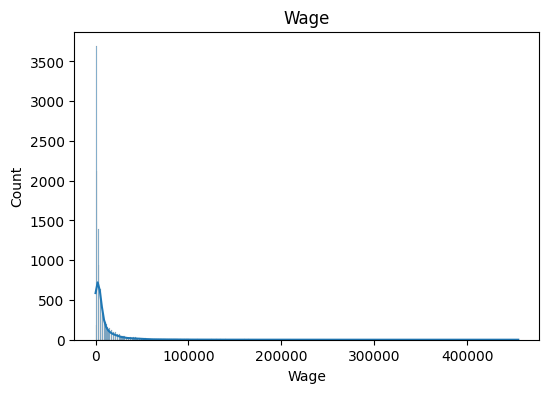

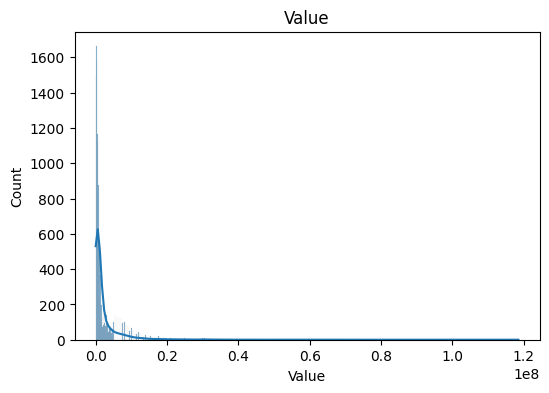

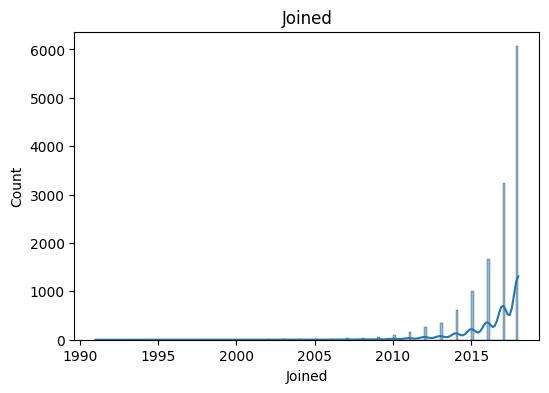

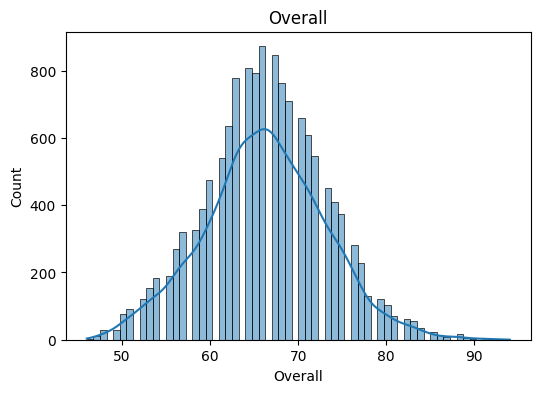

In [54]:
# plot dist (KDE/histogram)
import matplotlib.pyplot as plt
import seaborn as sns

for col in ['Wage', 'Value', 'Joined', 'Overall']:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()


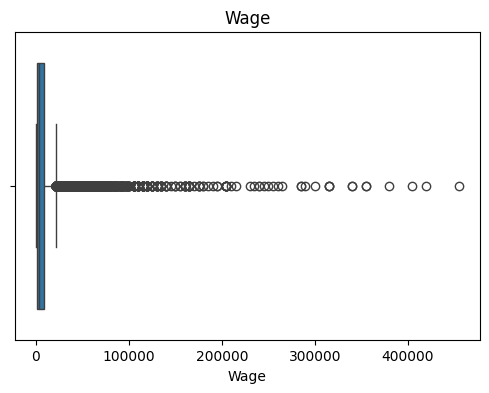

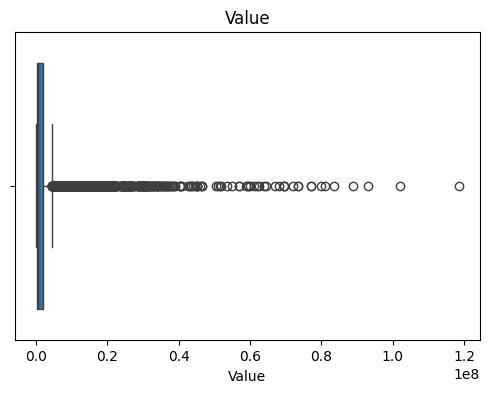

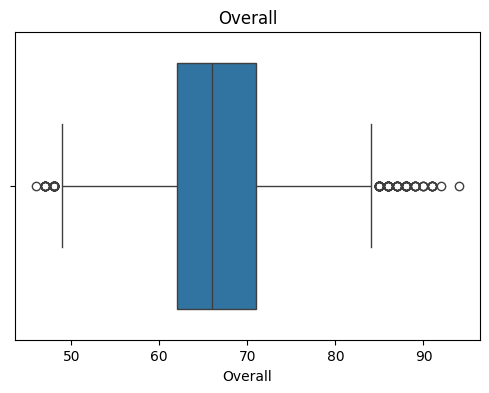

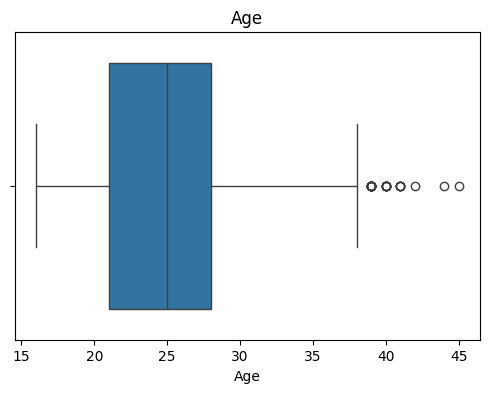

In [55]:
for col in ['Wage', 'Value', 'Overall', 'Age']:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [56]:
Q1 = df['Wage'].quantile(0.25)
Q3 = df['Wage'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 2*IQR
upper = Q3 + 2*IQR

outliers = df[(df['Wage'] < lower) | (df['Wage'] > upper)]

print(outliers[['Name', 'Wage']].head())
print(len(outliers))

            Name     Wage
2   P. Gazzaniga  46000.0
6   Z. Junuzović  39000.0
11       F. Fajr  28000.0
13     M. Zárate  26000.0
19    O. Al Soma  47000.0
1191


Distribution Analysis (Skewness & Outliers)

In this step, the distribution of numerical features was analyzed to understand skewness, data spread, and the presence of outliers.

---

### 1. Skewness Analysis

Skewness was calculated for all numerical features to understand the asymmetry of the data.

- Positive skewness indicates a long right tail (high-value outliers).
- Negative skewness indicates a long left tail (low-value outliers).
- Values close to zero indicate a symmetric (normal) distribution.

*Observations:*
- Features like *Wage, Value, and International Reputation* show high positive skewness, indicating the presence of extreme high values.
- Most skill-based features are slightly negatively skewed or nearly symmetric.
- *Overall rating* is approximately normally distributed.

---

### 2. Distribution Plots (Histogram & KDE)

Histogram and KDE plots were generated for selected features:
- Wage
- Value
- Joined
- Overall

*Observations:*
- *Wage and Value*:
  - Highly right-skewed distributions.
  - Majority of players have lower values, while a few have extremely high values.
- *Joined*:
  - Shows increasing trend in recent years, indicating more recent player entries.
- *Overall*:
  - Follows an approximately normal distribution.
  - Most players are concentrated around mid-range ratings.

---

### 3. Box Plot Analysis

Box plots were used to visualize the spread and detect outliers for:
- Wage
- Value
- Overall
- Age

*Observations:*
- *Wage and Value*:
  - Large number of extreme outliers observed.
- *Overall*:
  - Few mild outliers present.
- *Age*:
  - Slight right skew with some higher-age outliers.

---

### 4. Outlier Detection using IQR Method (2 × IQR as per requirement)

Outliers were detected using the Interquartile Range (IQR) method.

- Q1 (25th percentile) and Q3 (75th percentile) were calculated.
- IQR = Q3 - Q1

Outlier bounds were defined as:
- Lower Bound = Q1 - 2 × IQR
- Upper Bound = Q3 + 2 × IQR

Values outside these bounds were considered outliers.

*Results:*
- A total of 1191 outliers were identified in the Wage feature using the 2 × IQR method.
- Sample player names along with their wages were displayed.
- The total number of outliers was also calculated for analysis.

---

### Conclusion

- The dataset contains *highly skewed features*, especially Wage and Value.
- Significant *outliers are present*, particularly in financial attributes.
- Features like *Overall rating* are more normally distributed.
- Outlier detection using IQR helps in identifying extreme values for further preprocessing.

This step improves understanding of feature distributions and prepares the data for further modeling and transformation.

### Step 7: Extreme Outliers Detection using 2 * IQR

In [57]:
Q1 = df['Wage'].quantile(0.25)
Q3 = df['Wage'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 2 * IQR
upper = Q3 + 2 * IQR

extreme_outliers = df[(df['Wage'] < lower) | (df['Wage'] > upper)]

# Display sample players
print(extreme_outliers[['Name', 'Wage']].head())

# Total count
print("Total Extreme Outliers:", len(extreme_outliers))

            Name     Wage
2   P. Gazzaniga  46000.0
6   Z. Junuzović  39000.0
11       F. Fajr  28000.0
13     M. Zárate  26000.0
19    O. Al Soma  47000.0
Total Extreme Outliers: 1191


In this step, extreme outliers were identified using a stricter threshold of *2 × IQR*, as specified in the project requirements.

### Methodology:
- Q1 (25th percentile) and Q3 (75th percentile) were calculated for the *Wage* feature.
- IQR (Interquartile Range) = Q3 - Q1

Outlier boundaries were defined as:
- Lower Bound = Q1 - 2 × IQR
- Upper Bound = Q3 + 2 × IQR

Players whose Wage values fall outside these bounds were considered *extreme outliers*.

### Results:
- Extreme outliers were identified in the *Wage* feature.
- Sample player names along with their wages were displayed.
- A total of *1191 extreme outliers* were detected.

### Interpretation:
- These extreme values represent players with *exceptionally high wages* compared to the majority.
- Such outliers significantly impact statistical measures like mean and variance.
- This confirms the earlier observation that Wage is *highly positively skewed*.

### Conclusion:
- A large number of extreme outliers exist in the Wage feature.
- These values reflect real-world salary disparities among players.
- Proper handling (e.g., transformation or capping) may be required before modeling.

### Step 8: Categorical Analysis 

In [58]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\nColumn: {col}")
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts().head(10))


Column: Name
Unique values: 13019
Name
J. Rodríguez    8
R. Williams     6
J. Williams     6
J. Jones        5
L. Rodríguez    5
Felipe          5
Paulinho        5
F. Rodríguez    4
J. Murphy       4
Y. Kobayashi    4
Name: count, dtype: int64

Column: Nationality
Unique values: 160
Nationality
England        1240
Germany         908
Spain           807
France          690
Argentina       687
Brazil          623
Italy           511
Colombia        466
Japan           355
Netherlands     346
Name: count, dtype: int64

Column: Club
Unique values: 652
Club
Unknown                    185
AS Monaco                   29
Levante UD                  28
Empoli                      28
Tottenham Hotspur           28
Huddersfield Town           28
Leicester City              28
Wolverhampton Wanderers     27
Brentford                   27
Villarreal CF               27
Name: count, dtype: int64

Column: Preferred Foot
Unique values: 2
Preferred Foot
Right    10447
Left      3174
Name: count, dty

In this step, categorical variables were analyzed to identify data imbalance and cardinality issues.

### Methodology:
- Categorical columns were selected using object data type.
- The number of unique values was computed for each column.
- Frequency distribution (top 10 values) was analyzed using value counts.

---

### Observations:

#### 1. High Cardinality Features:
- *Name* contains a very high number of unique values (~13,000+), indicating extremely high cardinality.
- *Club* also has a large number of unique values (~600+), which may not be suitable for direct modeling.

These features may need to be:
- Dropped, or
- Encoded using advanced techniques if required.

---

#### 2. Data Imbalance:

- *Nationality*:
  - Countries like England, Germany, Spain, and France dominate the dataset.
  - Indicates imbalance across nationalities.

- *Work Rate*:
  - Majority of players fall under Medium/Medium category.
  - Other categories have significantly lower counts.

- *Body Type*:
  - Mostly concentrated in Normal and Lean categories.
  - Some rare categories (e.g., player-specific labels) appear only once.

- *Position*:
  - Some positions like ST, GK, CB are more frequent than others.
  - Shows moderate imbalance across positions.

---

### Conclusion:

- The dataset contains both *imbalanced categorical features* and *high cardinality variables*.
- Features like *Name* and *Club* may not be useful for modeling and can be removed or transformed.
- Imbalanced features should be handled carefully to avoid bias in modeling.
- Proper encoding techniques will be required before using categorical variables in machine learning models.

---

This analysis helps in understanding categorical feature behavior and prepares the dataset for further preprocessing.

### Step 9: Pair Plot

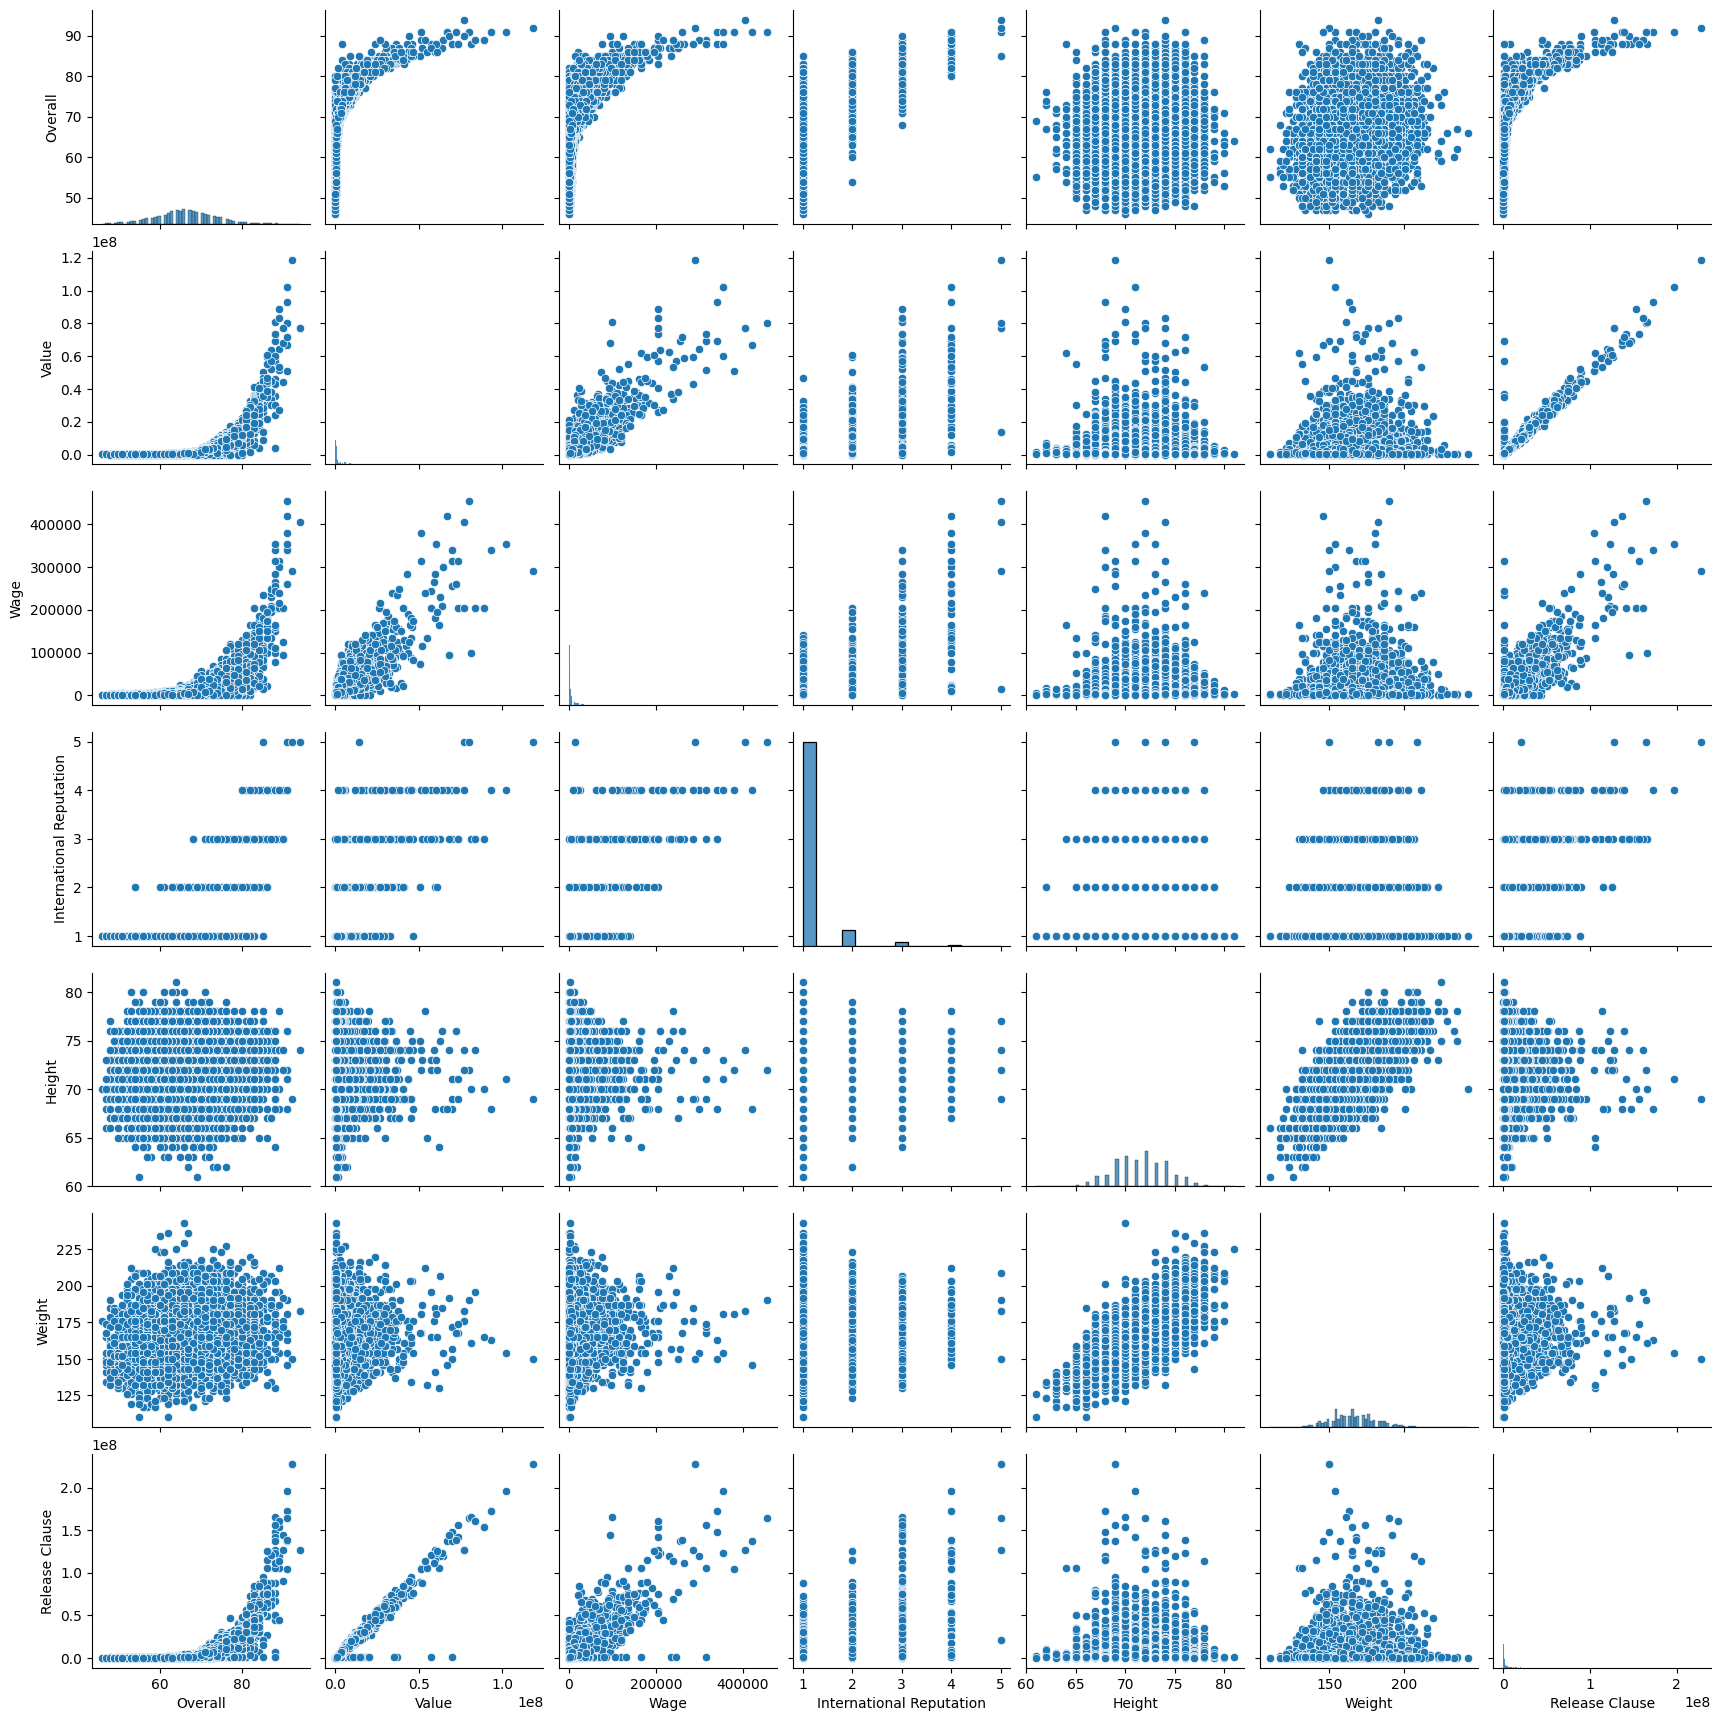

In [59]:
cols = ['Overall', 'Value', 'Wage', 'International Reputation', 
        'Height', 'Weight', 'Release Clause']

sns.pairplot(df[cols])
plt.show()

A pair plot was generated to visualize the relationships between key numerical variables in the dataset, including:

- Overall
- Value
- Wage
- International Reputation
- Height
- Weight
- Release Clause

### Observations:

- *Overall vs Value*:
  - Strong positive relationship observed.
  - Players with higher overall ratings tend to have significantly higher market value.

- *Value vs Release Clause*:
  - Very strong linear relationship.
  - Release clause is directly influenced by the player's market value.

- *Wage vs Value*:
  - Positive correlation present.
  - High-value players generally earn higher wages, though some variability exists.

- *International Reputation*:
  - Appears as discrete levels (1–5).
  - Higher reputation players are clustered among higher value and overall ratings.

- *Height vs Weight*:
  - Clear positive relationship.
  - Taller players tend to have higher weight.

- *Distribution Insights*:
  - Financial features such as *Value, Wage, and Release Clause* show right-skewed distributions.
  - Most players fall within lower value ranges, with a few high-value outliers.

### Conclusion:

The pair plot reveals strong relationships among financial and performance-related features. In particular:

- *Overall rating is a key driver of Value and Wage*
- *Release Clause is highly dependent on Value*
- Physical attributes like Height and Weight are naturally correlated

This analysis helps in understanding feature interactions and is useful for feature selection and modeling in later stages.

### Step 10: Analysis of Top 20 Players with Contract Expiry in 2020

In [69]:
# Convert 'Contract Valid Until' to datetime
df['Contract Valid Until'] = pd.to_datetime(df['Contract Valid Until'], errors='coerce')

# Filter players whose contract expires in 2020
players_2020 = df[df['Contract Valid Until'].dt.year == 2020]

# Check if data exists
players_2020.shape

(3042, 55)

In [70]:
# Top 20 players based on Overall rating
top20 = players_2020.sort_values(by='Overall', ascending=False).head(20)

# Display required columns
top20[['Name', 'Overall', 'Value', 'Wage', 'Age']]

,Name,Overall,Value,Wage,Age
20448,De Gea,91,72000000.0,260000.0,27
15989,Sergio Ramos,91,51000000.0,380000.0,32
963,E. Hazard,91,93000000.0,340000.0,27
6869,L. Modrić,91,67000000.0,420000.0,32
20440,G. Chiellini,89,27000000.0,215000.0,33
5874,C. Eriksen,88,73500000.0,205000.0,26
13954,Thiago Silva,88,24000000.0,165000.0,33
9293,D. Mertens,87,45000000.0,135000.0,31
13876,K. Navas,87,30500000.0,195000.0,31
8867,Jordi Alba,87,38000000.0,250000.0,29


In [71]:
# Average wage
avg_wage = top20['Wage'].mean()
avg_wage

np.float64(192950.0)

In [72]:
# Average age
avg_age = top20['Age'].mean()
avg_age

np.float64(30.05)

In [73]:
# Correlation between Overall and Value
corr = top20['Overall'].corr(top20['Value'])
corr

np.float64(0.7230702361058895)

In this step, players whose contracts expire in the year 2020 were filtered from the dataset. From this subset, the top 20 players were selected based on their Overall rating in descending order.

#### Key Analysis:

- Average Wage:  
  The average wage of the top 20 players is approximately 192,950, indicating that highly rated players tend to earn significantly higher salaries.

- Average Age:  
  The average age of these players is around 30 years, suggesting that top-performing players are generally experienced rather than very young.

- Correlation between Overall Rating and Value:  
  The correlation coefficient between Overall rating and Value is approximately 0.72, which indicates a strong positive relationship.  
  This means that players with higher performance ratings tend to have higher market values.

#### Conclusion:

The analysis shows that top players with contracts expiring in 2020 are highly valued, well-paid, and experienced. Additionally, there is a strong relationship between a player’s performance (Overall rating) and their market value, which aligns with real-world expectations in football analytics.

### Step 11: Position-wise Analysis of top 5 player by overall rating

In [78]:
# Top 5 players for each position
top5_by_position = (
    df.sort_values(by='Overall', ascending=False)
      .groupby('Position')
      .head(5)
)

In [75]:
# Find duplicate player names
duplicates = top5_by_position['Name'][top5_by_position['Name'].duplicated()]

duplicates.unique()

array([], dtype=object)

In [79]:
# Average wage for top 5 players in each position
avg_wage_position = top5_by_position.groupby('Position')['Wage'].mean()

avg_wage_position


Position
CAM    168000.0
CB     139600.0
CDM    179400.0
CF      42000.0
CM     132600.0
GK     164200.0
LAM     81800.0
LB     179600.0
LCB    158200.0
LCM     91800.0
LDM    105200.0
LF     121200.0
LM     135600.0
LS     105800.0
LW     261000.0
LWB     33800.0
RAM     46600.0
RB     136000.0
RCB    219000.0
RCM    218600.0
RDM    105000.0
RF      38600.0
RM     130000.0
RS     133800.0
RW     136200.0
RWB     41200.0
ST     294000.0
Name: Wage, dtype: float64

### Top 5 Players for Each Position
The dataset was grouped by player positions, and the top 5 players for each position were selected based on their Overall rating.

This was achieved by sorting the dataset in descending order of Overall rating and then selecting the top 5 players within each position group.

---

### Players Appearing in Multiple Positions
To check whether any players appear in more than one position among the top 5 lists, duplicate player names were identified.

*Result:*  
No players were found to appear in multiple position groups.

---

### Average Wage for Top 5 Players in Each Position
The average wage was calculated for the top 5 players in each position using group-wise aggregation.

*Observation:*  
- Different positions have varying average wages.
- Positions like *CDM, LB, CAM, and GK* tend to have relatively higher wages.
- Some attacking or less competitive positions show comparatively lower wages.

---

### Conclusion
This analysis highlights how player value and wages vary across different positions.  
It also confirms that top-performing players are uniquely distributed across positions without overlap in the top 5 lists.

### Step 12: Statistical Analysis

### 12.1: Comparison of Overall Ratings Between Left-Footed and Right-Footed Players

In [80]:
# split data
left = df[df['Preferred Foot'] == 'Left']['Overall'].dropna()
right = df[df['Preferred Foot'] == 'Right']['Overall'].dropna()

In [90]:
#normality test
from scipy.stats import shapiro

print("Left Foot Normality:", shapiro(left.sample(min(len(left), 5000))))
print("Right Foot Normality:", shapiro(right.sample(min(len(right), 5000))))

Left Foot Normality: ShapiroResult(statistic=np.float64(0.9951359051016015), pvalue=np.float64(9.929011303437719e-09))
Right Foot Normality: ShapiroResult(statistic=np.float64(0.9962208301416381), pvalue=np.float64(5.177436161736062e-10))


In [91]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(left, right, alternative='greater')

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 4.7128826809955555
P-value: 1.23326930795931e-06


#### Objective
To test whether left-footed players have a higher overall rating than right-footed players.

#### Hypotheses
- *Null Hypothesis (H₀):* Left-footed players do NOT have higher overall ratings than right-footed players.
- *Alternative Hypothesis (H₁):* Left-footed players have higher overall ratings than right-footed players.

#### Significance Level
- α = 0.05

#### Normality Test (Shapiro-Wilk Test)
- Left Foot p-value ≈ 9.92e-09  
- Right Foot p-value ≈ 5.17e-10  

Since both p-values are less than 0.05, the data is *not normally distributed*.  
However, due to the large sample size, we proceed with the t-test (Central Limit Theorem).

#### T-Test (Independent Sample, One-Tailed)
- T-statistic ≈ 4.71  
- P-value ≈ 1.23e-06 (≈ 0.00000123)

#### Decision
- Since p-value < 0.05, we *reject the null hypothesis*.

#### Conclusion
There is sufficient statistical evidence to conclude that *left-footed players have significantly higher overall ratings than right-footed players*.

### 12.2: Impact of Age on Player Potential (Age > 35 vs Age < 35)

In [92]:
older = df[df['Age'] > 35]['Potential'].dropna()
younger = df[df['Age'] < 35]['Potential'].dropna()

In [93]:
from scipy.stats import shapiro

print("Older Normality:", shapiro(older.sample(min(len(older), 5000))))
print("Younger Normality:", shapiro(younger.sample(min(len(younger), 5000))))

Older Normality: ShapiroResult(statistic=np.float64(0.9825202861737207), pvalue=np.float64(0.01231213332655345))
Younger Normality: ShapiroResult(statistic=np.float64(0.9946561324385352), pvalue=np.float64(1.167408490156181e-12))


In [94]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(older, younger, alternative='less')

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -7.364527116539499
P-value: 9.404570380254127e-14


#### Objective
To test whether players aged above 35 have lower potential than players aged below 35.

#### Hypotheses
- *Null Hypothesis (H₀):* Players aged > 35 do NOT have lower potential than players aged < 35.
- *Alternative Hypothesis (H₁):* Players aged > 35 have lower potential than players aged < 35.

#### Significance Level
- α = 0.05

#### Normality Test (Shapiro-Wilk Test)
- Older players p-value ≈ 0.012  
- Younger players p-value ≈ 1.17e-12  

Since both p-values are less than 0.05, the data is *not normally distributed*.  
However, due to the large sample size, we proceed with the t-test (Central Limit Theorem).

#### T-Test (Independent Sample, One-Tailed)
- T-statistic ≈ -7.36  
- P-value ≈ 9.40e-14  

#### Decision
- Since p-value < 0.05, we *reject the null hypothesis*.

#### Conclusion
There is sufficient statistical evidence to conclude that *players aged above 35 have significantly lower potential than players aged below 35*.

### 12.3: Relationship Between Preferred Foot and Player Position (Chi-Square Test with 99% Confidence Level)


In [96]:
# contingency table
ct = pd.crosstab(df['Preferred Foot'], df['Position'])
ct

Position,CAM,CB,CDM,CF,CM,GK,LAM,LB,LCB,LCM,...,RB,RCB,RCM,RDM,RF,RM,RS,RW,RWB,ST
Preferred Foot,,,,,,,,,,,,,,,,,,,,,
Left,202,253,99,11,195,159,7,863,198,75,...,10,26,30,19,3,189,29,74,2,210
Right,540,1074,622,43,874,1372,7,115,286,216,...,963,452,269,164,9,650,137,200,63,1376


In [97]:
# chi-square test

from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(ct)

print("Chi-square:", chi2)
print("P-value:", p)

Chi-square: 3380.83566514951
P-value: 0.0


#### Objective
To test whether there is a significant relationship between a player's preferred foot and their playing position.

#### Hypotheses
- *Null Hypothesis (H₀):* Preferred Foot and Player Position are independent.
- *Alternative Hypothesis (H₁):* Preferred Foot and Player Position are dependent.

#### Test Used
- Chi-Square Test of Independence  
- Significance Level (α) = 0.01 (99% Confidence Interval)

#### Results
- *Chi-square statistic:* 3380.84  
- *P-value:* ~0.0 (extremely small)

#### Decision
Since the p-value is less than the significance level (0.01), we reject the null hypothesis.

#### Conclusion
There is a statistically significant relationship between Preferred Foot and Player Position. This indicates that a player’s preferred foot influences their playing position distribution

### 12.4: Impact of International Reputation on Player Wages

In [98]:
# group wages by International Reputation
groups = [group['Wage'].dropna() for name, group in df.groupby('International Reputation')]

# normality check (optional but asked)
from scipy.stats import shapiro

for i, g in enumerate(groups):
    print(f"Group {i+1} Normality:", shapiro(g.sample(min(len(g), 5000))))

Group 1 Normality: ShapiroResult(statistic=np.float64(0.5700338580810208), pvalue=np.float64(6.399696529737338e-77))
Group 2 Normality: ShapiroResult(statistic=np.float64(0.8519073445508566), pvalue=np.float64(1.3262623804702528e-28))
Group 3 Normality: ShapiroResult(statistic=np.float64(0.915147332949883), pvalue=np.float64(5.216303966853308e-10))
Group 4 Normality: ShapiroResult(statistic=np.float64(0.960614853165815), pvalue=np.float64(0.21129856808429026))
Group 5 Normality: ShapiroResult(statistic=np.float64(0.8906644401690869), pvalue=np.float64(0.3861829739054966))


In [99]:
from scipy.stats import f_oneway

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 3474.986881355438
P-value: 0.0


#### Objective
To determine whether International Reputation has a significant effect on players' wages.

#### Hypotheses
- *Null Hypothesis (H₀):* Mean wages are equal across all levels of International Reputation.
- *Alternative Hypothesis (H₁):* At least one group has a different mean wage.

#### Test Used
- One-Way ANOVA (Analysis of Variance)  
- Significance Level (α) = 0.04

#### Results
- *F-statistic:* 3474.99  
- *P-value:* ~0.0 (extremely small)

#### Decision
Since the p-value is less than the significance level (0.04), we reject the null hypothesis.

#### Conclusion
There is a statistically significant difference in wages across different levels of International Reputation. This indicates that a player's reputation has a strong impact on their wages, with higher reputation players generally earning higher salaries.

### 12.5: Testing Median Wages of Top 20 Players

In [102]:
top20 = df.sort_values(by='Overall', ascending=False).head(20)
wages = top20['Wage'].dropna()

In [103]:
from scipy.stats import shapiro

print(shapiro(wages))

ShapiroResult(statistic=np.float64(0.9822244286704517), pvalue=np.float64(0.9594792257305788))


In [104]:
from scipy.stats import wilcoxon

stat, p_value = wilcoxon(wages - 25000)

print("Statistic:", stat)
print("P-value:", p_value)

Statistic: 0.0
P-value: 1.9073486328125e-06


We tested whether the median wage of the top 20 players is less than or equal to 25000.

Normality test (Shapiro-Wilk) showed p-value > 0.05, indicating normal distribution. However, since the test concerns the median, the Wilcoxon Signed-Rank Test was used.

The p-value obtained from the Wilcoxon test is 1.90e-06, which is less than the significance level of 0.05.

Therefore, we reject the null hypothesis.

Conclusion: The median wage of the top 20 players is significantly greater than 25000.